# Dataset description
## Deaths by Department
**Source**: DANE

**Download**: [DANE](https://www.dane.gov.co/index.php/estadisticas-por-tema/salud/nacimientos-y-defunciones/defunciones)

# Code
## Imports

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [75]:
path = "./data/departamento_muerte.csv"

df = pd.read_csv(path, encoding="utf-8", usecols=[0,1,2,3,4,5])

## Clean data

In [76]:
df["departamento"] = df["departamento"].apply(lambda x: x.title())
excl_b_a = df[~((df["departamento"].str.contains("11")) | (df["departamento"].str.contains("05")) | (df["departamento"].str.contains("Total")) | (df["departamento"].str.contains("76")))]
df_homicide = excl_b_a[excl_b_a["causa"].str.contains("101")]
most_deaths = df_homicide.groupby("departamento")["total"].sum().nlargest(5)
most_deaths_names = most_deaths.index.str.split(n=1).str[1]

per_year = df_homicide[df_homicide["departamento"].isin(most_deaths.index)]
per_year = per_year.groupby(["departamento", "Fecha"])["total"].sum()
per_year = per_year.reindex(most_deaths.index, level=0)

## Plot

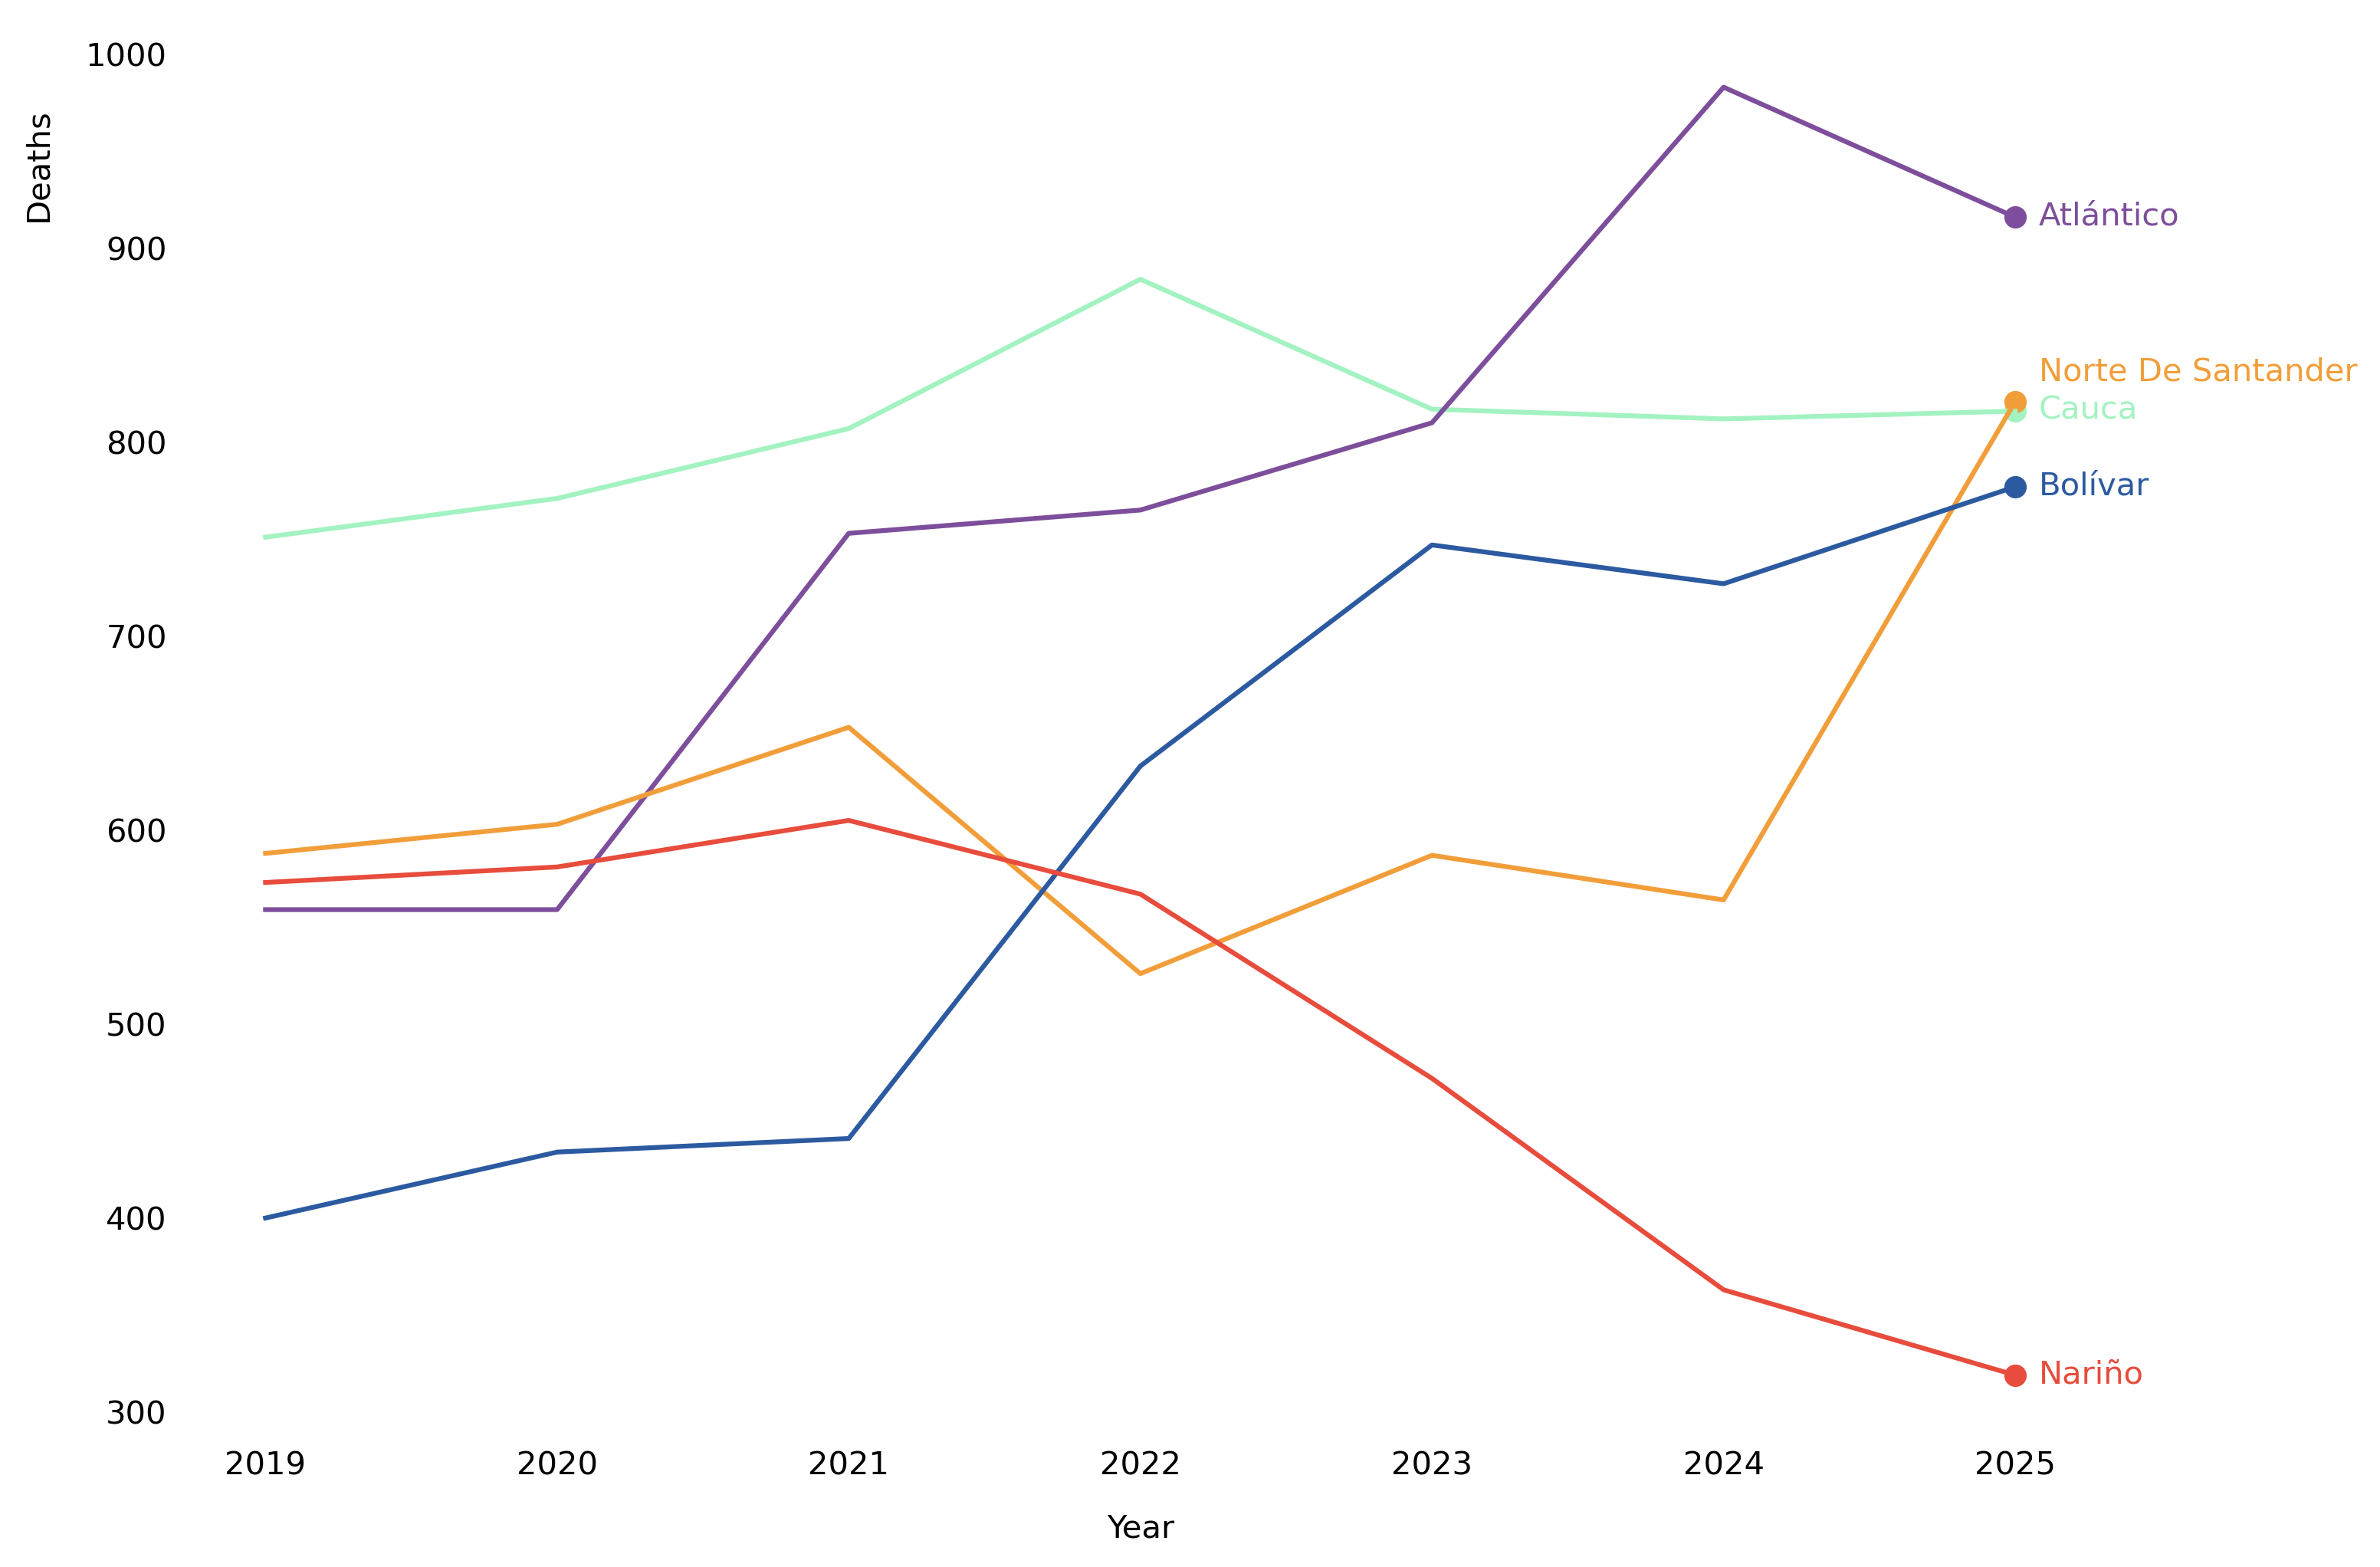

In [77]:
plt.figure(figsize=(10.8, 8), dpi=300)

colors = ["#a3f2c1", "#7d4e9b", "#f19e3a", "#2c5aa0", "#e74c3c"]

y_offsets = [0, 0, 15, 0, 0]

for i, name in enumerate(most_deaths.index):
    plt.plot(per_year[name], color=colors[i])
    plt.text(per_year[name].index[-1] + 0.08, per_year[name].values[-1] - 4 + y_offsets[i], most_deaths_names[i], color=colors[i])
    plt.scatter(per_year[name].index[-1], per_year[name].values[-1], color=colors[i])


for side in ["top", "left", "right", "bottom"]:
    plt.gca().spines[side].set_visible(False)

plt.tick_params(axis="x", length=0)
plt.tick_params(axis="y", length=0)

plt.xlabel("Year", labelpad=10, fontsize=10)
plt.ylabel("Deaths", labelpad=10, y=0.9, fontsize=10)

plt.show()